In [40]:
import os 
import pandas as pd
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, Flatten, BatchNormalization, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

In [41]:
happy = r'C:\Users\sarth\Downloads\archive (1)\happy'
sad = r'C:\Users\sarth\Downloads\archive (1)\sad'
angry = r'C:\Users\sarth\Downloads\archive (1)\angry'

In [42]:
categories = {
    0: "Angry", 1: "Happy", 2: "Sad"
}

labels = []
num_images = 2000  

happy_images = []
for idx, filename in enumerate(os.listdir(happy)):
    if idx >= 2000:
        break
    img = cv2.imread(os.path.join(happy, filename))
    if img is not None:
        happy_images.append(img)
        labels.append(0)

sad_images = []
for idx, filename in enumerate(os.listdir(sad)):
    if idx >= 2000:
        break
    img = cv2.imread(os.path.join(sad, filename))
    if img is not None:
        sad_images.append(img)
        labels.append(1)

angry_images = []
for idx, filename in enumerate(os.listdir(angry)):
    if idx >= 2000:
        break
    img = cv2.imread(os.path.join(angry, filename))
    if img is not None:
        angry_images.append(img)
        labels.append(2)

In [43]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

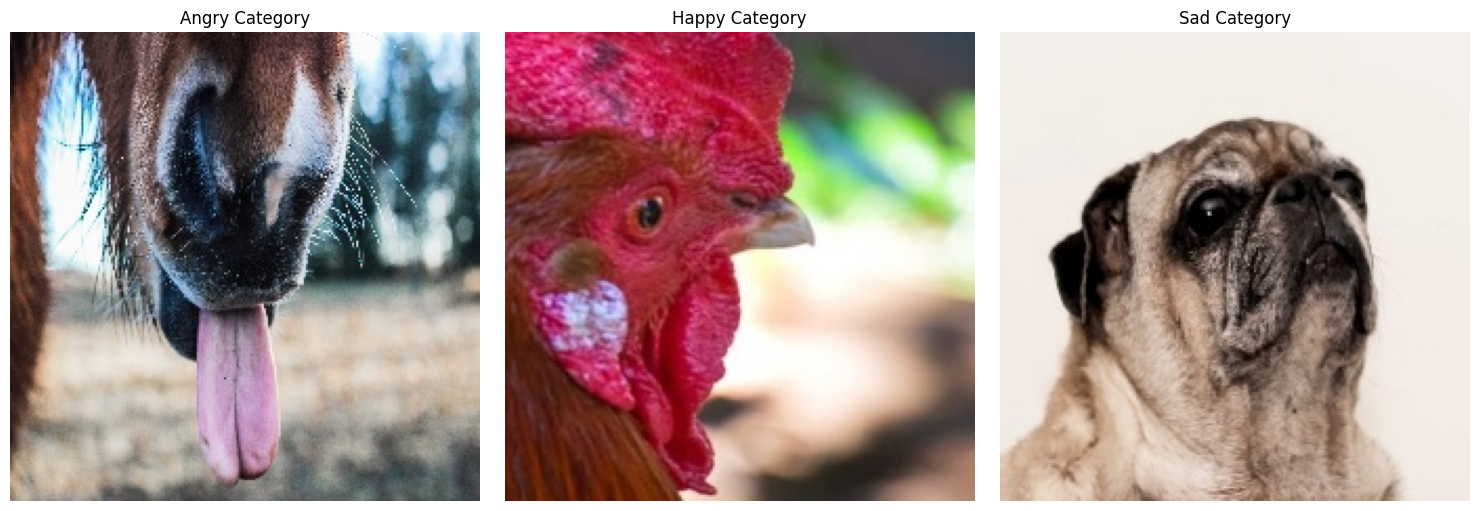

In [44]:
col = len(categories)
plt.figure(figsize=(15, 5))

category_images = {0: happy_images, 1: sad_images, 2: angry_images}

for i in range(col):
    random_image = random.choice(category_images[i])  
    gray_image = cv2.cvtColor(random_image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5)
    
    if len(faces) > 0:
        (x, y, w, h) = faces[0]  
        cropped_face = random_image[y:y+h, x:x+w]
        resized_face = cv2.resize(cropped_face, (128, 128))
    else:
        resized_face = cv2.resize(random_image, (128, 128))  

    plt.subplot(1, col, i+1)
    plt.imshow(cv2.cvtColor(random_image, cv2.COLOR_BGR2RGB)) 
    plt.title(f"{categories[i]} Category")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [45]:
data = []
labels = []
for idx, image_list in category_images.items():
    for image in image_list:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5)
        
        if len(faces) > 0:
            (x, y, w, h) = faces[0]
            cropped_face = image[y:y+h, x:x+w]
            resized_face = cv2.resize(cropped_face, (128, 128))
            data.append(resized_face)
            labels.append(idx)

data = np.array(data) / 255.0 

labels = np.array(labels)

print(f'Data shape: {data.shape}')
print(f'Labels shape: {labels.shape}')

Data shape: (40, 128, 128, 3)
Labels shape: (40,)


In [46]:
X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=0.2, random_state=42)

In [47]:
train_datagen = ImageDataGenerator(
    rotation_range=40,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_datagen.fit(X_train)

train_generator = train_datagen.flow(X_train, y_train, batch_size=32)
val_datagen = ImageDataGenerator(rotation_range=40,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)  
val_generator = val_datagen.flow(X_val, y_val, batch_size=32)
test_datagen = ImageDataGenerator(rotation_range=40,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
test_generator = test_datagen.flow(data, labels, batch_size=32)

In [48]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential()

# Add convolutional and pooling layers
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(512, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Add dense layers
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.00015),  # Directly use Adam
    metrics=['accuracy']
)

# Display the model's architecture
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)            │ (None, 126, 126, 64)  │        1,792 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_12        │ (None, 126, 126, 64)  │          256 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_25 (Conv2D)            │ (None, 124, 124, 64)  │       36,928 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_12              │ (None, 62, 62, 64)    │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_16 (Dropout)          │ (None, 62, 62, 64)    │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_26 (Conv2D)            │ (None, 60, 60, 128)   │       73,856 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_13        │ (None, 60, 60, 128)   │          512 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_27 (Conv2D)            │ (None, 58, 58, 128)   │      147,584 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_13              │ (None, 29, 29, 128)   │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_17 (Dropout)          │ (None, 29, 29, 128)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_28 (Conv2D)            │ (None, 27, 27, 512)   │      590,336 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ batch_normalization_14        │ (None, 27, 27, 512)   │        2,048 │
│ (BatchNormalization)          │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_29 (Conv2D)            │ (None, 25, 25, 512)   │    2,359,808 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_14              │ (None, 12, 12, 512)   │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_18 (Dropout)          │ (None, 12, 12, 512)   │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ flatten_4 (Flatten)           │ (None, 73728)         │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_11 (Dense)              │ (None, 512)           │   37,749,248 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_19 (Dropout)          │ (None, 512)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_12 (Dense)              │ (None, 3)             │        1,539 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 40,963,907 (156.26 MB)

 Trainable params: 40,962,499 (156.26 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the model
history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[early_stopping, lr_reduction]
)

# Print training and validation accuracy for each epoch
for i in range(len(history.history['accuracy'])):
    print(f"Epoch {i + 1}: Training Accuracy: {history.history['accuracy'][i]:.4f}, "
          f"Validation Accuracy: {history.history.get('val_accuracy', [0])[i]:.4f}")


Epoch 1/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.3438 - loss: 2.3807 - val_accuracy: 0.7500 - val_loss: 0.9210 - learning_rate: 1.5000e-04
Epoch 2/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4375 - loss: 25.3754 - val_accuracy: 0.1250 - val_loss: 1.1983 - learning_rate: 1.5000e-04
Epoch 3/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2812 - loss: 39.6023 - val_accuracy: 0.1250 - val_loss: 1.1598 - learning_rate: 1.5000e-04
Epoch 4/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2812 - loss: 20.1188 - val_accuracy: 0.1250 - val_loss: 1.0866 - learning_rate: 1.5000e-04
Epoch 5/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3438 - loss: 12.2458 - val_accuracy: 0.2500 - val_loss: 1.0404 - learning_rate: 7.5000e-05
Epoch 6/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 11.3821 - val_accuracy: 0.7500 - val_loss: 1.0041 - learning_rate: 7.5000e-05
Epoch 7/40
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4688 - loss: 13.4514 - val

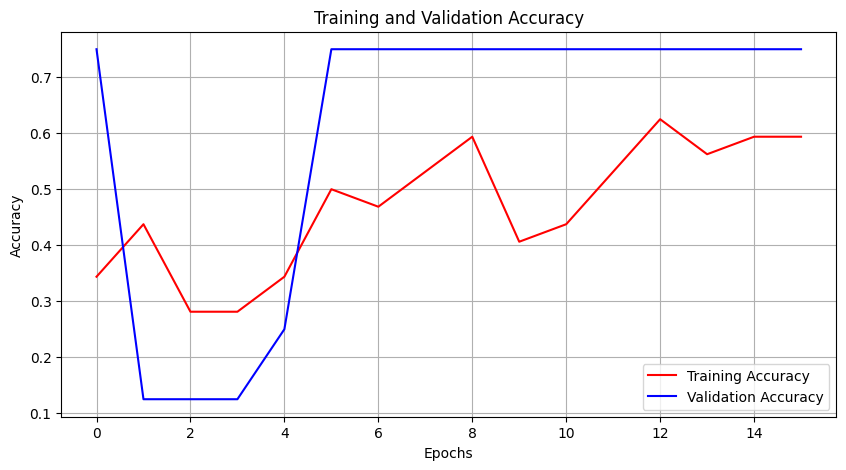

In [50]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='red')  
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')  
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.grid(True) 
plt.show()

In [51]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.5167 - loss: 1.0711
Test Loss: 1.0590, Test Accuracy: 0.5250


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 974ms/stepWARNING:tensorflow:6 out of the last 9 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002CE5BE6B560> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step


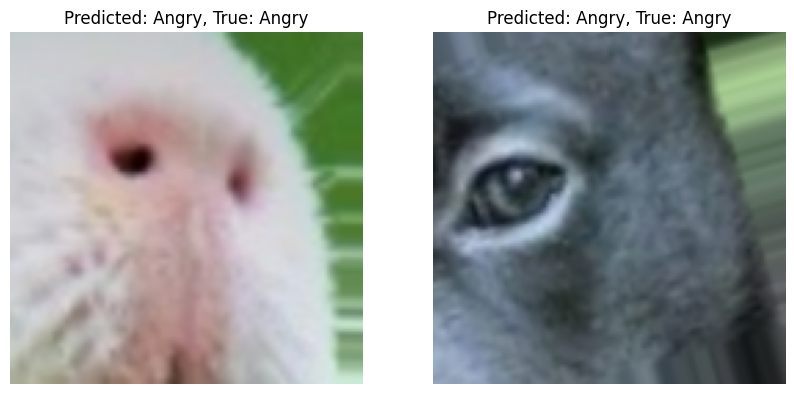

In [52]:
predictions = model.predict(test_generator)
predicted_classes = (predictions > 0.5).astype("int32")

plt.figure(figsize=(10, 10))

label_map = {0: "Angry", 1: "Happy", 2: "Sad"}

num_batches = len(test_generator)

random_indices = random.sample(range(num_batches), 2)

for i in random_indices:
    img_batch, true_label_batch = test_generator[i]
    image = img_batch[0]
    true_label = true_label_batch[0]  

    true_label_index = np.argmax(true_label_batch[0])  

    image = image * 255.0  
    image = image.astype(np.uint8)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, random_indices.index(i) + 1)
    plt.imshow(image_rgb)  
    plt.title(f'Predicted: {label_map[predicted_classes[i][0]]}, True: {label_map[true_label_index]}')
    plt.axis('off')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step


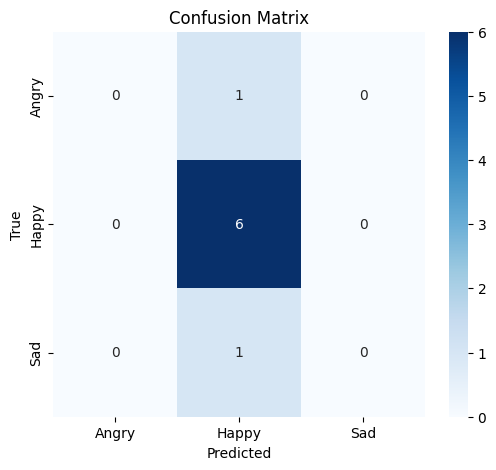

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the validation set
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_val, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories.values(), yticklabels=categories.values())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [54]:
from sklearn.metrics import classification_report

# Assuming you have the true labels (y_true) and predicted labels (y_pred)
y_true = y_val  # True labels
y_pred = model.predict(val_generator)  # Predicted labels

# Convert predictions to class labels (use argmax if necessary)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print classification report
report = classification_report(y_true, y_pred_classes, target_names=list(categories.values()))
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
              precision    recall  f1-score   support

       Angry       0.00      0.00      0.00         1
       Happy       0.75      1.00      0.86         6
         Sad       0.00      0.00      0.00         1

    accuracy                           0.75         8
   macro avg       0.25      0.33      0.29         8
weighted avg       0.56      0.75      0.64         8

